In [1]:
import os
os.chdir("/home/mbatt/gravitational_lensing")

In [2]:
import requests

url = "https://zenodo.org/records/15025832/files/modeling_lens_mass.csv"
output_path = "modeling_lens_mass.csv"

r = requests.get(url)
r.raise_for_status()

with open(output_path, "wb") as f:
    f.write(r.content)

print("Downloaded successfully!")

Downloaded successfully!


In [3]:
import pandas as pd

modeling_lens_mass = pd.read_csv('modeling_lens_mass.csv', index_col = 0)

In [4]:
import os

os.chdir('/net/GECO/nas13c/flame/euclid/Q1_results')

In [5]:
ls

euclid_color_grid.png   modeling_lens_mge.csv
group/                  modeling_lens_sersic.csv
group.zip               modeling_mge_magnitude.csv
lens/                   modeling_sersic_magnitude.csv
lens_cutouts/           q1_discovery_engine_lens_catalog.csv
lens_cutouts.csv        recenter.zip
lens.zip                resnetmini.png
modeling_lens_mass.csv  unsuccess.zip


In [6]:
df_paths_file = pd.read_csv('lens_cutouts.csv', index_col = 0)

In [7]:
folder =  "/net/GECO/nas13c/flame/euclid/Q1_results/lens_cutouts/102160612_2743600657683668805"
fits_files = [f for f in os.listdir(folder)]
fits_files

['102160612_2743600657683668805_EUC_MER_BGSUB-MOSAIC-NIR-H_TILE101839132-C84DD1_20250817T093034.430001Z_00.00.fits',
 '102160612_2743600657683668805_EUC_MER_BGSUB-MOSAIC-CFIS-R_TILE102160612-D925C5_20250714T064027.382579Z_00.00.fits',
 '102160612_2743600657683668805_EUC_MER_BGSUB-MOSAIC-WISHES-Z_TILE101839132-A6A880_20250817T090044.445682Z_00.00.fits',
 '102160612_2743600657683668805_EUC_MER_BGSUB-MOSAIC-PANSTARRS-I_TILE102160612-2B6777_20250708T225716.408577Z_00.00.fits',
 '102160612_2743600657683668805_EUC_MER_BGSUB-MOSAIC-VIS_TILE101839132-54A60B_20250817T124648.462136Z_00.00.fits',
 '102160612_2743600657683668805_EUC_MER_BGSUB-MOSAIC-WISHES-I2_TILE101839132-724D81_20250817T090046.441776Z_00.00.fits',
 '102160612_2743600657683668805_EUC_MER_BGSUB-MOSAIC-NIR-J_TILE101839132-FF9A26_20250817T093058.373648Z_00.00.fits',
 '102160612_2743600657683668805_EUC_MER_BGSUB-MOSAIC-WISHES-G_TILE101839132-F6770F_20250817T090043.385703Z_00.00.fits',
 '102160612_2743600657683668805_EUC_MER_BGSUB-MOS

In [8]:
folder =  "/net/GECO/nas13c/flame/euclid/Q1_results/lens_cutouts/"
fits_files = [f for f in os.listdir(folder)]

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
ppaths=  "/net/GECO/nas13c/flame/euclid/Q1_results/lens_cutouts/102160612_2743600657683668805/102160612_2743600657683668805_EUC_MER_BGSUB-MOSAIC-VIS_TILE101839132-54A60B_20250817T124648.462136Z_00.00.fits"
# folders = sorted(os.listdir(base_dir))[0]   # ← fix: define folders

with fits.open(ppaths) as hdul:
    print(hdul[0].header
         )
    # Try ext 1 first (Euclid MER standard), fall back to 0
    # ext = 1 if len(hdul) > 1 and hdul[1].data is not None else 0

SIMPLE  =                    T / Java FITS: Thu Jun 04 09:30:53 CEST 2026       BITPIX  =                  -32 / bits per data element                          NAXIS   =                    2                                                  NAXIS1  =                  600                                                  NAXIS2  =                  600                                                  EXTEND  =                    T / allow extensions                               EQUINOX =        2000.00000000 / Mean equinox                                   RADESYS = 'ICRS    '           / Astrometric system                             CUNIT1  = 'deg     '           / Axis unit                                      CD1_1   =  -2.777777777778E-05 / Linear projection matrix                       CD1_2   =   0.000000000000E+00 / Linear projection matrix                       CUNIT2  = 'deg     '           / Axis unit                                      CD2_1   =   0.000000000000E+00 / Linear 

In [10]:
2.777777777778E-05 * 3600

0.100000000000008

In [11]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
folders = [f for f in os.listdir() if 'csv' not in f]
folders[0]
ddilesx = [file for file in os.listdir(folders[0]) if '.fits' in file]
print(folders[0], ddilesx[0])

final_hscsearch_2e3_26 lens_51398_source_1143_r_1.fits


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

ppaths=  "/home/rcanameras/data/mock_lenses_hsc/final_hscsearch_2e3_26/lens_51398_source_1143_r_1.fits"

with fits.open(ppaths) as hdul:
    print(hdul[0].header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  END                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

Loaded 64 objects


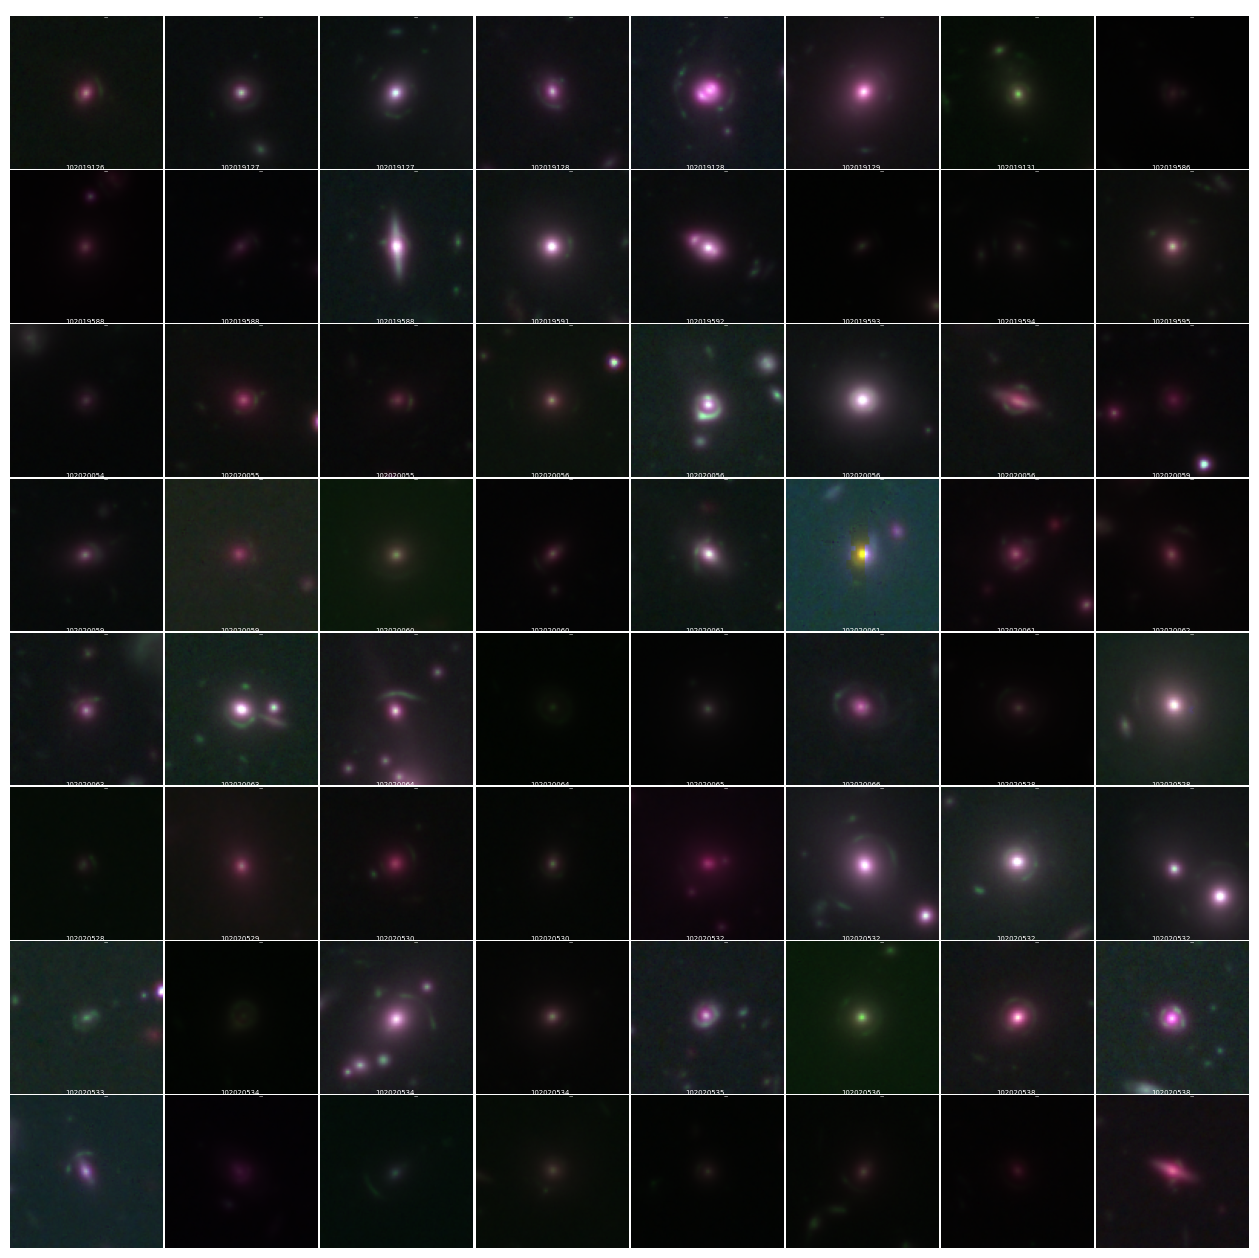

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

base_dir = "/net/GECO/nas13c/flame/euclid/Q1_results/lens_cutouts/"
folders = sorted(os.listdir(base_dir))[:64]   # ← fix: define folders

def load_band(path):
    with fits.open(path) as hdul:
        # Try ext 1 first (Euclid MER standard), fall back to 0
        ext = 1 if len(hdul) > 1 and hdul[1].data is not None else 0
        img = hdul[ext].data.astype(float)
    img = np.nan_to_num(img)
    # img = (img - np.nanmin(img))/(np.nanmax(img)) 
    # img =  np.arcsinh(10 * img)/np.arcsinh(10)
    p1, p99 = np.percentile(img, [0, 99.996])
    if p99 > p1:
        img = np.clip(img, p1, p99)
        img = (img - p1) / (p99 - p1)
    else:
        img[:] = 0
    # img = (img)/(np.nanmax(img))
    # img = np.arcsinh(img)
    img = np.sqrt(img)
    # img = np.sqrt(10 * img)/np.sqrt(10)
    # img =  np.arcsinh(10 * img)/np.arcsinh(10)
    return img

def find_band(files, keywords):
    for f in files:
        if any(k in f for k in keywords):
            return f
    return None

images = []
labels = []

for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    try:
        files = [f for f in os.listdir(folder_path)]
    except Exception:
        continue
    
    red_file   = find_band(files, ["NIR-H"])
    green_file = find_band(files, ["VIS"]) # NIR-H
    blue_file  = find_band(files, ["NIR-Y"])

    # if None in (red_file, green_file, blue_file):
    #     print(f"  Missing band in {folder}, skipping")
    #     continue

    R = load_band(os.path.join(folder_path, red_file))
    G = load_band(os.path.join(folder_path, green_file))
    B = load_band(os.path.join(folder_path, blue_file))

    h = min(R.shape[0], G.shape[0], B.shape[0])
    w = min(R.shape[1], G.shape[1], B.shape[1])
    R, G, B = R[:h, :w], G[:h, :w], B[:h, :w]
    rgb = np.dstack([R, G, B])

    # safe crop: only if image is large enough
    crop = 250
    if h > 2 * crop and w > 2 * crop:
        rgb = rgb[crop:-crop, crop:-crop]

    images.append(rgb)
    labels.append(folder)

print(f"Loaded {len(images)} objects")

# --- Plot ---
ncols, nrows = 8, 8
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))
plt.subplots_adjust(wspace=0.01, hspace=0.01)

for ax in axes.flat:
    ax.axis("off")

for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i] , origin="lower")
        ax.set_title(labels[i][:10], fontsize=5, pad=1, color="white")  # optional ID label

# plt.savefig("euclid_color_grid.png", dpi=150, bbox_inches="tight",
            # facecolor="black")
plt.show()

In [13]:
from deep_learning_models import *

In [14]:
folder =  "/net/GECO/nas13c/flame/euclid/Q1_results/lens_cutouts/"
fits_files = [f for f in os.listdir(folder)]

In [15]:
path_image = "/net/GECO/nas13c/flame/euclid/Q1_results/lens_cutouts/"
save_path = "/net/CLUSTER/VAULT/users/mbatt/data_euclid/"

In [16]:
import torch
from astropy.io import fits
import numpy as np

def save_fits_as_tensor(arr, save_path):
    # arr is dimension 4 
    tensor = torch.tensor(arr, dtype=torch.float32)
    torch.save(tensor, save_path)

In [17]:
import random
from tqdm import tqdm
import os
import random

def find_band(files, keywords):
    for f in files:
        if any(k in f for k in keywords):
            return f
    return None
    
def load_band(path):
    with fits.open(path) as hdul:
        ext = 1 if len(hdul) > 1 and hdul[1].data is not None else 0
        img = hdul[ext].data.astype(float)
    # img = np.nan_to_num(img)
    # p1, p99 = np.percentile(img, [0, 99.996])
    # if p99 > p1:
    #     img = np.clip(img, p1, p99)
    #     img = (img - p1) / (p99 - p1)
    # else:
    #     img[:] = 0
    # img = np.sqrt(img)
    return img
    
for ima_file in tqdm(df_paths_file.index):
    folder_path = os.path.join(folder, ima_file)
    files = [f for f in os.listdir(folder_path)]
    try : 
        red_file   = find_band(files, ["NIR-H"])
        green_file = find_band(files, ["NIR-J"]) # NIR-H
        blue_file  = find_band(files, ["NIR-Y"])
        bb = find_band(files, ["VIS"])
        
        R = load_band(os.path.join(folder_path, red_file))
        G = load_band(os.path.join(folder_path, green_file))
        B = load_band(os.path.join(folder_path, blue_file))
        B2 = load_band(os.path.join(folder_path, bb))
    
        # h = min(R.shape[0], G.shape[0], B.shape[0], B2.shape[0])
        # w = min(R.shape[1], G.shape[1], B.shape[1], B2.shape[1])
        # R, G, B, B2 = R[:h, :w], G[:h, :w], B[:h, :w], B2[:h, :w]
        rgb = np.stack([R, G, B, B2], axis = 0)
    
        target_size = 224
        
        h, w = rgb.shape[1], rgb.shape[2]
        c = random.randint(10, 20)
        # print(c)
        if h >= target_size and w >= target_size:
            start_h = (h - target_size) // 2
            start_w = (w - target_size) // 2
        
            rgb = rgb[
                :,
                start_h-c:start_h-c + target_size,
                start_w-c:start_w + target_size-c
            ]
    
        save_fits_as_tensor(rgb, save_path + ima_file +  ".pt")
        print('saved')
    except:
        pass

  0%|▎                                                                                        | 1/334 [00:00<02:29,  2.22it/s]

saved


  1%|▌                                                                                        | 2/334 [00:00<02:14,  2.47it/s]

saved


  1%|▊                                                                                        | 3/334 [00:01<02:05,  2.65it/s]

...

saved


100%|██████████████████████████████████████████████████████████████████████████████████████▋| 333/334 [02:25<00:00,  2.25it/s]

saved


100%|███████████████████████████████████████████████████████████████████████████████████████| 334/334 [02:26<00:00,  2.29it/s]

saved


In [18]:
files = [f for f in os.listdir("/net/CLUSTER/VAULT/users/mbatt/data_euclid/")]
len(files)

333

In [19]:
class LensDataset_euclid(Dataset):
    def __init__(self, df, path_tensor_folder):
        self.df = df
        self.path = path_tensor_folder

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        tensor_path = os.path.join(self.path, row.name + '.pt')
        x = torch.load(tensor_path)
        
        x = torch.clamp(x, min=0)
        x_min = x.amin(dim=(1, 2), keepdim=True)
        x_max = x.amax(dim=(1, 2), keepdim=True)
        # print(x_min.shape, x_max.shape)
        x = (x - x_min) / (x_max - x_min + 1e-8)
        x = torch.sqrt(x)
        y = torch.tensor(row.values, dtype=torch.float32)
        return x, (y, row.name) 

In [20]:
df_paths_file = df_paths_file[
    df_paths_file.index != "102044187_NEG538533000282255459"
]

In [21]:
import pandas as pd
dff = pd.read_csv('/home/mbatt/gravitational_lensing/ready_data.csv', index_col = 0)

In [22]:
import torch
from torch.utils.data import random_split

path_tensor = "/net/CLUSTER/VAULT/users/mbatt/data_euclid/"
full_dataset = LensDataset_euclid(df_paths_file, path_tensor)
test_loader = DataLoader(full_dataset, batch_size=32, shuffle=False, num_workers=3)

# path_tensor = "/home/mbatt/data"
# full_dataset = LensDataset_UNet(dff, path_tensor)
# train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
#                                                                 test_pct = 0.2, # 20% for test
#                                                                 batch_size = 32)

In [23]:
model = UNetThenResNet()
model = ResNetHoliSmokes()

In [24]:
model.model_name

'ResNetHoliSmokes'

In [25]:
# vv = viewer(model)
# vv.show_model()

In [26]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 1,260,229
Trainable parameters: 1,260,229


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

os.chdir("/home/mbatt/gravitational_lensing")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# checkpoint = torch.load(f"{model.model_name}_16.pth", map_location=device)
checkpoint = torch.load(f"{model.model_name}_22.pth", map_location=device)


model.load_state_dict(checkpoint["model"])
optimizer.load_state_dict(checkpoint["optimizer"])

start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]


/tmp/ipykernel_827556/493553386.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f"{model.model_name}_22.pth", map_location=device)


In [28]:
def cheat(imgi):
    H = []
    for j in range(len(imgi)):
        L = []
        for i in range(4):
            img = imgi[j,i,:,:].cpu()
            img = abs(img)
            img = np.nan_to_num(img)
            # p1, p99 = np.percentile(img, [0, 99.996])
            p1, p99 = np.percentile(img, [0, 99.996])
            if p99 > p1:
                img = np.clip(img, p1, p99)
                img = (img - p1) / (p99 - p1)
            else:
                img[:] = 0
            img = np.sqrt(img)
            L.append(img)
        N = np.stack(L, axis = 0)
        H.append(N)
    H = np.stack(H, axis = 0)
    return torch.tensor(H, dtype=torch.float32)

In [29]:
model.eval()
preds = []
targets = []
lens_only = []
paths = []
image = []
criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        xb = xb.to(device)
        ms = xb[:,0,:,:].mean(dim=(1, 2))
        image.append(ms)
        # xb = xb[:,-1,:,:]
        # xb = xb[0].to(device)
        yb, ps = yb[0].to(device), yb[1]

        # out_lens = model.forward_unet(xb)
        # outputs = model.forward_resnet(out_lens)
        outputs = model(xb)
        
        preds.append(outputs.cpu())
        targets.append(yb.cpu())
        paths += ps

# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)
means = torch.cat(image)
df_final = pd.DataFrame({'Objid' : paths, 'Prediction_r_einstein' : preds.cpu().numpy()[:,0], 'Target_r_einstein' : targets.cpu().numpy()[:,0]})

/tmp/ipykernel_827556/4048788566.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_827556/4048788566.py:12: FutureWarning: You 

In [38]:
path_tensor = "/home/mbatt/data"
full_dataset = LensDataset_UNet(dff, path_tensor)
train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, # 20% for test
                                                                batch_size = 32)

In [39]:
i = 0
image = []
for kk in test_loader:
    ms = kk[0][0][:,0,:,:].mean(dim=(1, 2))
    image.append(ms)
simuu = torch.cat(image)


/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/deep_learning_models.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/net/CLUSTER/VAULT

KeyboardInterrupt: 

In [ ]:
len(simuu.cpu().numpy())

In [ ]:
import matplotlib.pyplot as plt
plt.hist(simuu.cpu().numpy(), bins = 100, edgecolor = 'black')
plt.grid(True)
plt.show()

In [ ]:
plt.hist(means.cpu().numpy(), bins = 30, edgecolor = 'black')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# pred and targ are tensors of shape (4, 140, 140)
# choose one band, e.g. i-band (index 2)
pred_arr = xb[2,0,:,:].cpu().numpy()
targ_arr = kk[0][0][2,0,:,:].cpu().numpy()

# --- Downsample by averaging 4×4 blocks ---
def downsample_4x4(arr):
    h, w = arr.shape
    arr = arr[:h - (h % 4), :w - (w % 4)]  # ensure divisible by 4
    arr = arr.reshape(h//4, 4, w//4, 4).mean(axis=(1, 3))
    return arr

pred_ds = downsample_4x4(pred_arr)   # shape (35, 35)
# targ_ds = downsample_4x4(targ_arr)   # shape (35, 35)

# --- Prepare grid for bar3d ---
nx, ny = pred_ds.shape
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y, indexing='ij')

x_flat = xx.ravel()
y_flat = yy.ravel()
z_flat = np.zeros_like(x_flat)

pred_flat = pred_ds.ravel()

dx = dy = 1

# --- Plot side-by-side ---
fig = plt.figure(figsize=(16, 7))

# LEFT: prediction
ax1 = fig.add_subplot(121, projection='3d')
ax1.bar3d(x_flat, y_flat, z_flat, dx, dy, pred_flat,
          shade=True, color='royalblue', alpha=0.9)
ax1.set_title("Prediction (downsampled 4×4)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Value")

targ_ds = downsample_4x4(targ_arr)   # shape (35, 35)

# --- Prepare grid for bar3d ---
nx, ny = targ_ds.shape
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y, indexing='ij')

x_flat = xx.ravel()
y_flat = yy.ravel()
z_flat = np.zeros_like(x_flat)

pred_flat = pred_ds.ravel()

dx = dy = 1
targ_flat = targ_ds.ravel()
# RIGHT: target
ax2 = fig.add_subplot(122, projection='3d')
ax2.bar3d(x_flat, y_flat, z_flat, dx, dy, targ_flat,
          shade=True, color='darkorange', alpha=0.9)
ax2.set_title("Target (downsampled 4×4)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Value")

plt.tight_layout()
plt.show()


In [38]:
df_final.Prediction_r_einstein.mean()

0.4988353

In [30]:
import pandas as pd
import numpy as np
df = pd.read_csv("mock_lenses_hsc.csv")
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

In [31]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")

In [32]:
folders = [f for f in os.listdir() if 'csv' not in f]
dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]
df_full = df.merge(df_im, on = "objID", how = 'left')
df_sample = df_full#.sample(n=2000, random_state=42)

In [33]:
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

In [34]:
# df_final_2 = df_final
# df_final_2['Prediction_r_einstein'] = df_final_2['Prediction_r_einstein']* (df_max[0] - df_min[0]) + df_min[0]
# df_final_2['Target_r_einstein'] = df_final_2['Target_r_einstein'] * (df_max[0] - df_min[0]) + df_min[0]

In [35]:
df_final_2 = df_final.merge(modeling_lens_mass[['id_str', 'einstein_radius_effective_max_lh']], left_on = 'Objid', right_on = 'id_str', how = 'left')
df_final_2['pred_r_einstein_denorm'] = df_final_2['Prediction_r_einstein'] * (df_max[0] - df_min[0]) + df_min[0]
df_final_2 = df_final_2.dropna()
df_final_2 = df_final_2[df_final_2['einstein_radius_effective_max_lh'] != 0]

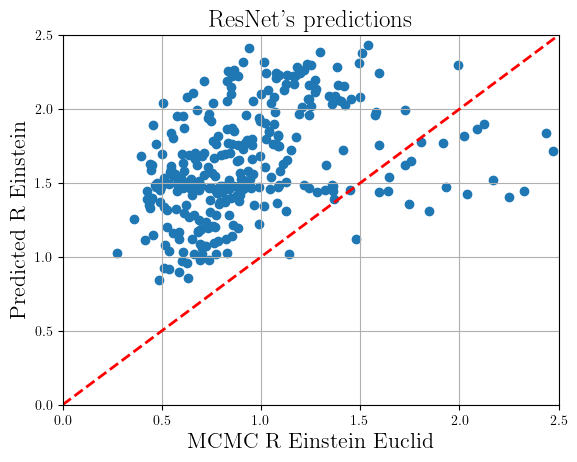

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]
# plt.scatter(df_final_2['Target_r_einstein'], df_final_2['Prediction_r_einstein'])
plt.scatter(
    df_final_2['einstein_radius_effective_max_lh'],
    df_final_2['pred_r_einstein_denorm']
)

# diagonal line (y = x)
x = np.linspace(0, 2.5, 100)
plt.plot(x, x, 'r--', linewidth=2)

plt.grid(True)
plt.xlabel('MCMC R Einstein Euclid', fontsize=16)
plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.title("ResNet's predictions", fontsize=18)
plt.ylabel('Predicted R Einstein', fontsize=16)

plt.show()

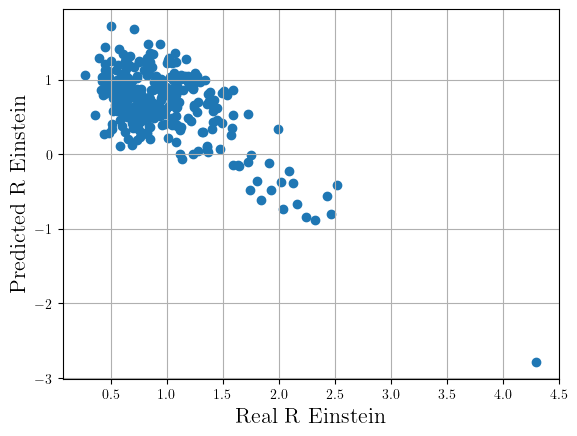

In [52]:
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

plt.scatter(df_final_2['einstein_radius_effective_max_lh'], df_final_2['pred_r_einstein_denorm'] - df_final_2['einstein_radius_effective_max_lh'])
# plt.scatter(df_final_2['Target_r_einstein'], df_final_2['Prediction_r_einstein'])
plt.grid(True)
plt.xlabel('Real R Einstein', fontsize = 16)
plt.ylabel('Predicted R Einstein', fontsize = 16)
plt.show()

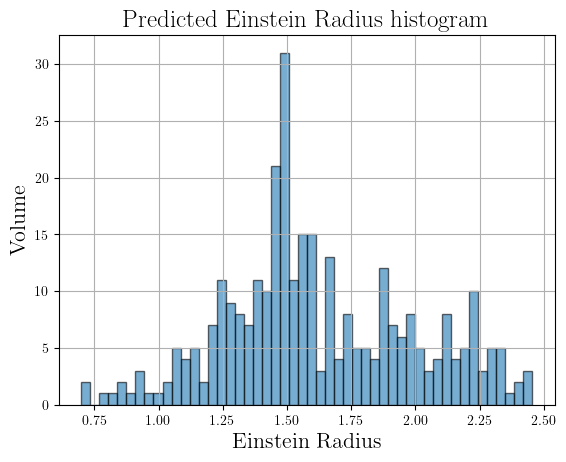

In [53]:
plt.hist(df_final_2['pred_r_einstein_denorm'], bins = 50, alpha = 0.6, edgecolor = 'black')
plt.title('Predicted Einstein Radius histogram', fontsize = 18)
plt.xlabel('Einstein Radius', fontsize = 16)
plt.ylabel('Volume', fontsize = 16)
plt.grid(True)
plt.show()

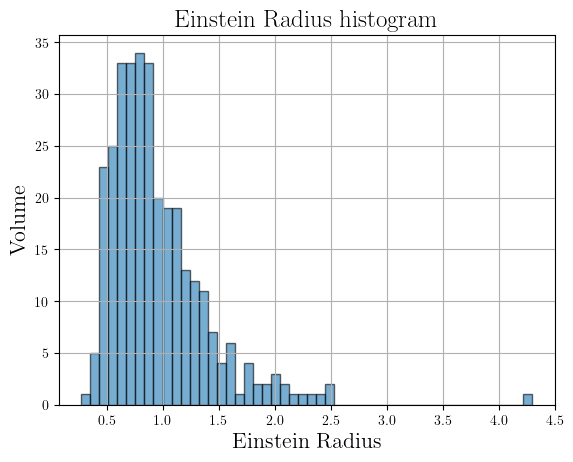

In [54]:
plt.hist(df_final_2['einstein_radius_effective_max_lh'], bins = 50, alpha = 0.6, edgecolor = 'black')
plt.title('Einstein Radius histogram', fontsize = 18)
plt.xlabel('Einstein Radius', fontsize = 16)
plt.ylabel('Volume', fontsize = 16)
plt.grid(True)
plt.show()

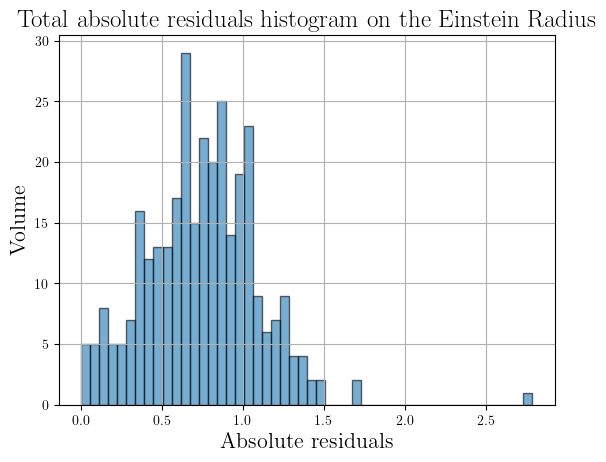

In [55]:
plt.hist(abs(df_final_2['einstein_radius_effective_max_lh'] - df_final_2['pred_r_einstein_denorm']), bins = 50, alpha = 0.6, edgecolor = 'black')
plt.title('Total absolute residuals histogram on the Einstein Radius', fontsize = 18)
plt.xlabel('Absolute residuals', fontsize = 16)
plt.ylabel('Volume', fontsize = 16)
plt.grid(True)
plt.show()

<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_242297/20477762.py:35: SyntaxWarning: invalid escape sequence '\s'
  f"$+ \sigma$ = {sigma_plus:.2f}\n"
/tmp/ipykernel_242297/20477762.py:36: SyntaxWarning: invalid escape sequence '\s'
  f"$- \sigma$ = {sigma_minus:.2f}"


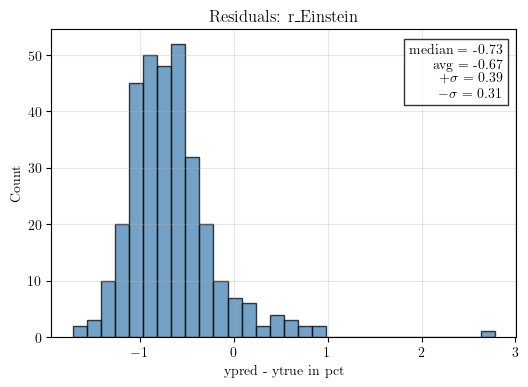

In [56]:
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# --- Compute denormalised errors ---
error_denorm = df_final_2['einstein_radius_effective_max_lh'] - df_final_2['pred_r_einstein_denorm']
# error_denorm = error_denorm/df_final_2['einstein_radius_effective_max_lh'] * 100

# error_denorm = df_final_2['Target_r_einstein'] - df_final_2['Prediction_r_einstein']

# --- Asymmetric statistics ---
medians = np.median(error_denorm)
p16 = np.percentile(error_denorm, 16)
p84 = np.percentile(error_denorm, 84)

sigma_minus = medians - p16
sigma_plus  = p84 - medians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# --- Plot ---
fig = plt.figure(figsize=(6, 4))

plt.hist(error_denorm, bins=30, alpha=0.75,
         color="steelblue", edgecolor="black")
plt.title(f"Residuals: {param_names[0]}")
plt.xlabel("ypred - ytrue in pct")
plt.ylabel("Count")
plt.grid(alpha=0.3)

# --- Add text box with denormalised stats ---
text = (
    f"median = {medians:.2f}%\n"
    f"avg = {np.mean(error_denorm):.2f}%\n"
    f"$+ \sigma$ = {sigma_plus:.2f}\n"
    f"$- \sigma$ = {sigma_minus:.2f}"
)

plt.text(
    0.97, 0.95, text,
    transform=plt.gca().transAxes,
    fontsize=10,
    ha="right", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
)

# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/unet_8_resnet_hist_residus.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
path_tensor = "/net/CLUSTER/VAULT/users/mbatt/data_euclid/"
full_dataset = LensDataset_euclid(df_paths_file, path_tensor)
test_loader = DataLoader(full_dataset, batch_size=32, shuffle=False, num_workers=3)

In [50]:
model.eval()
preds = []
targets = []
lens_only = []
paths = []

criterion = nn.MSELoss(reduction="none")
i = 0
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        if i < 3 :
            xb = xb.to(device)
            ybc, ps = yb[0].to(device), yb[1]
    
            out_lens = model.forward_unet(xb)
            outputs = model.forward_resnet(out_lens)
            
            preds.append(outputs.cpu())
            targets.append(ybc.cpu())
            paths += ps
            i += 1
        else:
            break
ddff = pd.DataFrame({'Objid' : ps, 'pred_einstein' : outputs.cpu().numpy()[:,0]})
# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)
df_final = pd.DataFrame({'Objid' : paths, 'Prediction_r_einstein' : preds.cpu().numpy()[:,0], 'Target_r_einstein' : targets.cpu().numpy()[:,0]})

/tmp/ipykernel_189886/121852211.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_189886/121852211.py:12: FutureWarning: You ar

In [51]:
ddff = ddff.merge(modeling_lens_mass[['id_str', 'einstein_radius_effective_max_lh']], left_on = 'Objid', right_on = 'id_str', how = 'left')
ddff['pred_einstein'] = ddff['pred_einstein'] * (df_max[0] - df_min[0]) + df_min[0]
ddff = ddff.dropna()
ddff = ddff[ddff['pred_einstein'] != 0]
del ddff['Objid']
ddff.index = ddff['id_str']
del ddff['id_str']

/tmp/ipykernel_189886/1669242606.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(path_tensor + paths[k] + '.pt')


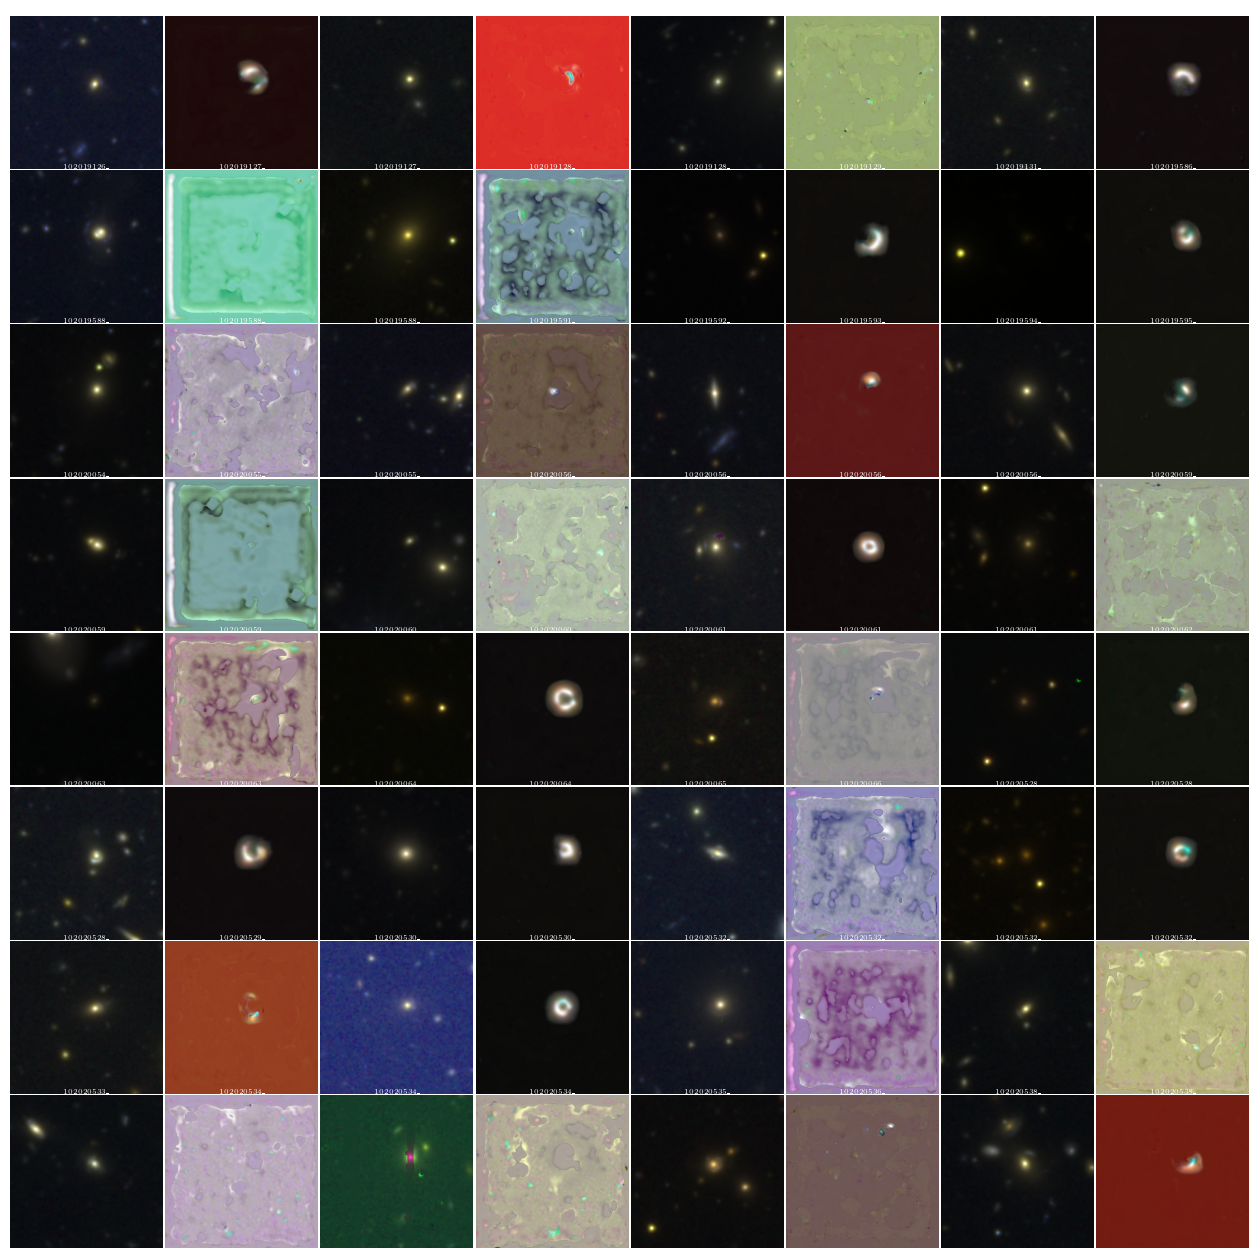

In [54]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

def showswho(imgi):
    L = []
    for i in range(3):
        img = imgi[:,:,i]
        img = np.nan_to_num(img)
        # p1, p99 = np.percentile(img, [0, 99.996])
        p1, p99 = np.percentile(img, [0, 99.996])
        if p99 > p1:
            img = np.clip(img, p1, p99)
            img = (img - p1) / (p99 - p1)
        else:
            img[:] = 0
        img = np.sqrt(img)
        L.append(img)
    return np.dstack(L)

path_tensor = "/net/CLUSTER/VAULT/users/mbatt/data_euclid/"
images = []

for k in range(32):
    x = torch.load(path_tensor + paths[k] + '.pt')
    x = x.numpy()
    # x = abs(x)
    # x = x[3]
    x = np.dstack([x[0], x[1], x[-1]])
    # images.append(x)
    images.append(showswho(x))

    y = out_lens[k].cpu().numpy()
    # y = np.dstack([y[0], y[1], y[-1]])
    y = np.dstack([y[0],y[1], y[-1]])
    # y = abs(y)
    # y = y**2
    # y = y[3]
    # images.append(1/y)
    images.append(showswho(y))
    # images.append(abs(y))
    
    
# --- Plot ---
ncols, nrows = 8, 8
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))
plt.subplots_adjust(wspace=0.01, hspace=0.01)

for ax in axes.flat:
    ax.axis("off")

for i, ax in enumerate(axes.flat):
    if i < len(images):
        if i%2 !=0:
            im = ax.imshow(images[i], origin="lower")
        else:
            im = ax.imshow(images[i], origin="lower")
        ax.set_title(labels[i][:10], fontsize=5, pad=1, color="white")  # optional ID label
        # plt.colorbar(im, ax=ax)

# plt.savefig("euclid_color_grid.png", dpi=150, bbox_inches="tight",
#             facecolor="black")
# plt.colorbar(images[i], orientation='vertical', pad=0.01, fraction=0.04)
plt.show()

In [55]:
ddff['residual'] = ddff['pred_einstein'] - ddff['einstein_radius_effective_max_lh']
ddff

,pred_einstein,einstein_radius_effective_max_lh,residual
id_str,,,
102020539_NEG639239120489296299,2.194718,1.418634,0.776084
102020539_NEG640534948489252606,1.189602,0.814877,0.374725
102020539_NEG641383802490968352,1.018171,0.681124,0.337047
102021006_NEG554672577486973111,2.006841,0.829341,1.177500
102021008_NEG569571426487440793,1.018793,0.592537,0.426257
102021009_NEG577024787484062221,1.019838,2.323862,-1.304024
102021010_NEG581199679484613010,2.238004,1.204348,1.033656
102021012_NEG594963796484947260,1.367459,1.756304,-0.388845
102021013_NEG602940269483238112,1.020283,1.181791,-0.161508


In [ ]:
ybc.shape


In [ ]:
u = torch.load(path_tensor + paths[k] + '.pt')
for uu in u:
    print(uu.mean())

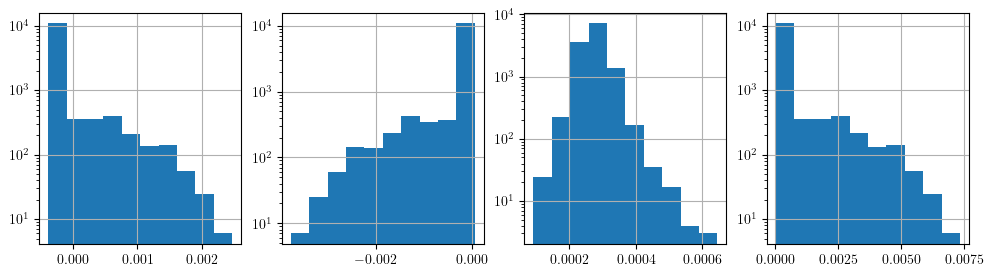

In [179]:
fig, axes = plt.subplots(1,4, figsize = (12,3))
for j in range(4):
    ax = axes[j]
    ax.hist(out_lens[0][j].cpu().numpy().flatten(), log = True)
    ax.grid(True)
plt.show()

In [44]:
for k in range(4):
    print(showswho(y)[k].mean())

0.40845707
0.45104158
0.4458056
0.4488421


In [57]:
def rms(x):
    return torch.sqrt(torch.mean(x**2, dim=(-2, -1)))

def compute_noise(Liste, image, squarre):
    # Extract 5x5 corners
    tl = image[..., 0:squarre, 0:squarre]
    tr = image[..., 0:squarre, -squarre:]
    bl = image[..., -squarre:, 0:squarre]
    br = image[..., -squarre:, -squarre:]

    # RMS per corner → [B, 4]
    rms_tl = rms(tl)
    rms_tr = rms(tr)
    rms_bl = rms(bl)
    rms_br = rms(br)

    # Stack → [B, 4, 4]
    rms_all = torch.stack([rms_tl, rms_tr, rms_bl, rms_br], dim=-1)

    # Minimum RMS across corners → [B, 4]
    rms_min = rms_all.min(dim=-1).values

    Liste.append(rms_min.cpu())
    return Liste

In [58]:
model.eval()

Noise_t = []
Noise_p = []
Signal_t = []
Signal_p = []

squarre = 20
criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb, _ = yb[0].to(device), yb[1]

        optimizer.zero_grad()
        # ---- Forward pass ----
        out_lens = model.forward_unet(xb)
        outputs = model.forward_resnet(out_lens)
        Noise_t = compute_noise(Noise_t, xb, squarre)
        signal_batch = xb.sum(dim=(-1, -2))
        Signal_t.append(signal_batch.cpu())
# Concatenate all batches
Noise_t = torch.cat(Noise_t, dim=0) 
Signal_t = torch.cat(Signal_t, dim=0) # shape [N, 4]
# Compute ratio
Ratio_t = Signal_t / Noise_t

/tmp/ipykernel_2789/630939183.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_2789/630939183.py:12: FutureWarning: You are us

In [80]:
model.eval()
preds = []
targets = []
lens_only = []
paths = []

criterion = nn.MSELoss(reduction="none")
i = 0
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here

        xb = xb.to(device)
        yb, ps = yb[0].to(device), yb[1]

        out_lens = model.forward_unet(xb)
        outputs = model.forward_resnet(out_lens)
        
        preds.append(outputs.cpu())
        targets.append(yb.cpu())
        paths += ps
        i += 1

            
# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)
df_final = pd.DataFrame({'Objid' : paths, 'Prediction_r_einstein' : preds.cpu().numpy()[:,0], 'Target_r_einstein' : targets.cpu().numpy()[:,0]})

/tmp/ipykernel_112088/630939183.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_112088/630939183.py:12: FutureWarning: You ar

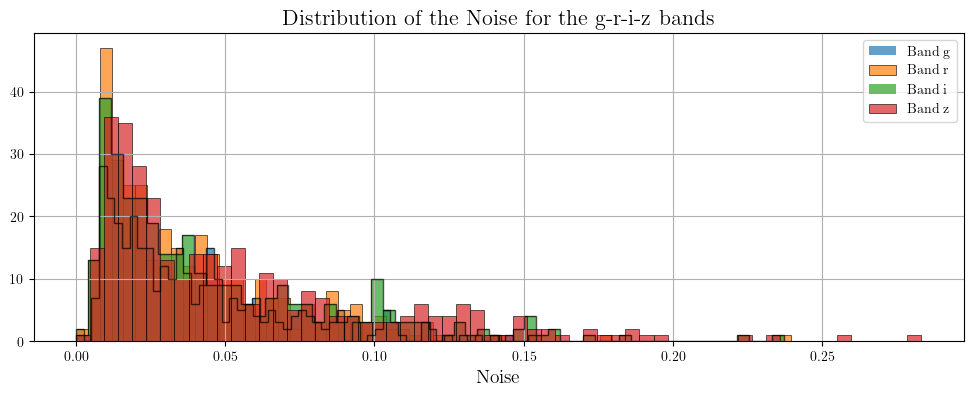

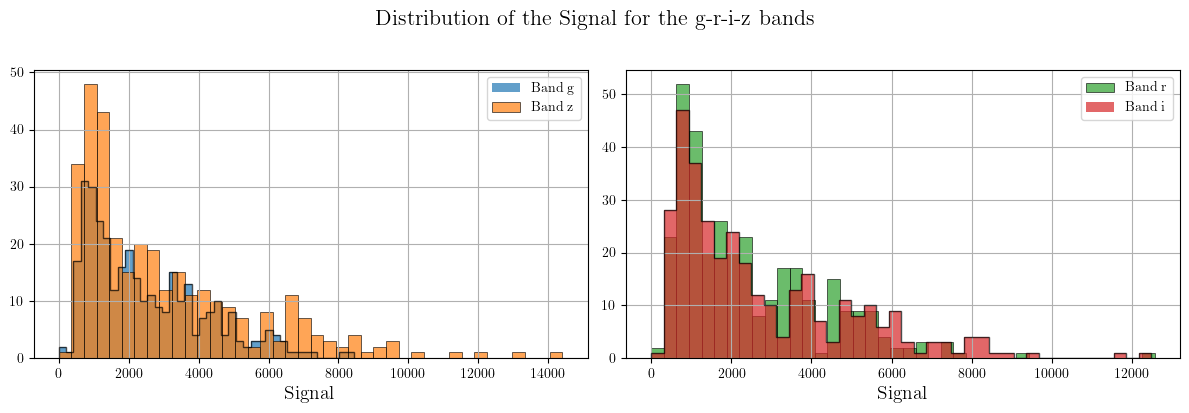

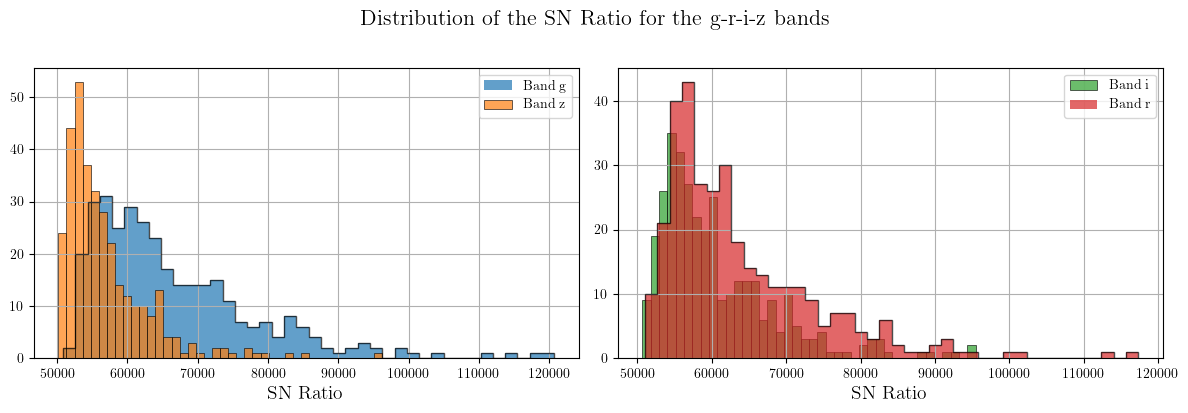

In [64]:
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]


fig, axis = plt.subplots(1,1, figsize = (12,4))
bandes = ['g', 'r', 'i', 'z']
binss = 40
bins_s = 60

ax = axis
# counts, bins, _ = ax.hist(Noise_t[:,0][Noise_t[:,0] < 0.6], bins=200, alpha=0.7, label = f'Band {bandes[0]}',histtype='step')
# # result = [x for x in bins[1:] for _ in range(2)]
# ax.plot(bins[:-1], counts, color='black', linewidth=0.7)
ax.hist(Noise_t[:,0], bins=bins_s, alpha=0.7, label = f'Band {bandes[0]}')
ax.hist(Noise_t[:,0], bins=bins_s, alpha=0.7, histtype='step', linewidth = 1, color = 'black')

ax.hist(Noise_t[:,1], bins= bins_s, label = f'Band {bandes[1]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)

ax.hist(Noise_t[:,2], bins=bins_s, alpha=0.7, label = f'Band {bandes[2]}')
ax.hist(Noise_t[:,2], bins=bins_s, alpha=0.7, histtype='step', linewidth = 1, color = 'black')

ax.hist(Noise_t[:,3][Noise_t[:,3] < 0.3], bins= bins_s, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)

ax.set_title(f"Distribution of the Noise for the g-r-i-z bands",fontsize=16)
ax.grid(True)
ax.set_xlabel('Noise', fontsize=14)
ax.legend()
plt.show()

fig, axis = plt.subplots(1,2, figsize = (12,4))
ax = axis[0]
ax.hist(Signal_t[:,0], bins=binss, alpha=0.7, label = f'Band {bandes[0]}')
ax.hist(Signal_t[:,0], bins=binss, alpha=0.7, histtype='step', linewidth = 1, color = 'black')

ax.hist(Signal_t[:,3][Signal_t[:,3] <15000], bins= binss, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
ax.grid(True)
ax.set_xlabel('Signal', fontsize=14)
ax.legend()

ax = axis[1]

ax.hist(Signal_t[:,1], bins= binss, color = '#2ca02c', label = f'Band {bandes[1]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)

ax.hist(Signal_t[:,2],color = '#d62728', bins=binss, alpha=0.7, label = f'Band {bandes[2]}')
ax.hist(Signal_t[:,2], bins=binss, alpha=0.7, histtype='step', linewidth = 1, color = 'black')


ax.grid(True)
ax.set_xlabel('Signal',fontsize=14)
ax.legend()

fig.suptitle("Distribution of the Signal for the g-r-i-z bands",
             fontsize=16, y=1.02)
plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/sn_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axis = plt.subplots(1,2, figsize = (12,4))
ax = axis[0]
ax.hist(Ratio_t[:,0], bins=binss, alpha=0.7, label = f'Band {bandes[0]}')
ax.hist(Ratio_t[:,0], bins=binss, alpha=0.7, histtype='step', linewidth = 1, color = 'black')
ax.hist(Ratio_t[:,3], bins= binss, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
ax.grid(True)
ax.set_xlabel('SN Ratio', fontsize=14)
ax.legend()

ax = axis[1]
ax.hist(Ratio_t[:,2], bins= binss, color = '#2ca02c', label = f'Band {bandes[2]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
ax.hist(Ratio_t[:,1],color = '#d62728', bins=binss, alpha=0.7, label = f'Band {bandes[1]}')
ax.hist(Ratio_t[:,1], bins=binss, alpha=0.7, histtype='step', linewidth = 1, color = 'black')
ax.grid(True)
ax.set_xlabel('SN Ratio',fontsize=14)
ax.legend()

fig.suptitle("Distribution of the SN Ratio for the g-r-i-z bands",
             fontsize=16, y=1.02)
plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/sn_ratio.png", dpi=300, bbox_inches="tight")
plt.show()
    